Supplementary Code S1 — Data import, exploratory analysis, quality control, and feature governance

This notebook implements data ingestion, harmonization, exploratory quality control, and feature governance starting exclusively from the original source database (klotho_data_base.xlsx). It produces a clean, outcome-agnostic dataset snapshot together with structured metadata required for all downstream modeling, validation, and robustness analyses (Supplementary Codes S2–S11).

Each row in the dataset corresponds to a unique patient record.

At this stage, no outcome-driven filtering, feature selection, imputation, scaling, normalization, model fitting, or performance evaluation is performed.

Crucially, all operations in Supplementary Code S1 are restricted to preprocessing and metadata annotation only, ensuring that no information leakage from outcome variables or post-baseline clinical events can influence downstream analyses.

Key processing steps
Raw data import and auditability

Import of the original Excel database (klotho_data_base.xlsx).

Preservation of an unmodified raw snapshot (df_raw.parquet) for full auditability and reproducibility.

Feature name harmonization

Systematic normalization of column names (lowercasing, ASCII normalization, delimiter standardization).

Generation of a one-to-one mapping between original and harmonized feature names (column_name_map.csv).

Type coercion with explicit logging

Controlled coercion of binary and numeric variables based on data-driven heuristics.

All conversions are explicitly logged in coercion_log.csv.

No imputation or value modification is performed beyond type harmonization.

Exploratory missingness assessment

Quantitative evaluation of missing data patterns across all features.

Generation of a comprehensive missingness summary (missingness_summary.csv).

Duplicate and identifier screening

Detection of duplicated rows and potential patient identifiers.

Identification of candidate identifier variables based on naming patterns and value duplication.

No automatic record removal is performed at this stage.

Physiological plausibility checks

Identification (but not automatic exclusion) of values outside predefined physiological ranges (e.g., age, BMI).

All detected out-of-range values are recorded in qc_out_of_range.csv for transparent audit.

Feature governance and role assignment

A structured data dictionary (data_dictionary.csv) is constructed, assigning each feature a governance role:

clinical

biomarker

id

exclude

target

Roles are assigned solely based on feature semantics and naming conventions (regex-based rules), without reference to outcome distributions.

Importantly, governance roles define metadata only and do not by themselves determine inclusion in specific modeling variants.

Definition of feature variants (pre-modeling layer)

Based on governance roles and firewall exclusions, three predefined feature variants are deterministically constructed and saved to feature_variants.json:

FULL — all retained clinical and biomarker features.

CLINICAL (strict) — baseline clinical variables and routine admission laboratory parameters only, explicitly excluding research-level cytokines and biomarker assay variables.

BIOMARKERS — molecular and circulating biomarker variables, including cytokines and assay-based protein measurements.

The assignment of features to these variants is rule-based and deterministic. Variant definitions are frozen at this stage and reused unchanged in all downstream analyses.

This explicit separation ensures that comparisons between clinical-only and biomarker-based models reflect genuine structural differences in feature sets rather than downstream analytical decisions.

Leakage-aware feature firewall (governance only)

Identification of features that could encode outcome information, post-baseline events, or procedural interventions (e.g., discharge status, revascularization, mortality).

Such features are flagged and excluded from downstream modeling via governance rules.

Keyword-based leakage scans are performed to ensure that no feature name directly encodes outcome information.

Importantly, this step does not involve any statistical association with the outcome variable.

Scope and methodological constraints

No outcome-based filtering or feature selection is performed.

No imputation, scaling, normalization, or model training is applied.

No statistical association between predictors and outcomes is evaluated.

All decisions are deterministic, rule-based, and fully logged.

This strict separation ensures that Supplementary Code S1 remains entirely outcome-agnostic, providing a transparent and reproducible foundation for all subsequent modeling and validation steps.

Outputs (written to PROC_DIR)

df_raw.parquet — raw data snapshot after import.

df_clean.parquet — cleaned and harmonized dataset used as input for downstream modeling.

column_name_map.csv — mapping between original and standardized feature names.

data_dictionary.csv — structured feature metadata and governance information.

missingness_summary.csv — quantitative overview of missing data patterns.

coercion_log.csv — explicit log of type coercion operations.

qc_out_of_range.csv — audit table of values outside expected physiological ranges.

feature_variants.json — frozen definitions of FULL, CLINICAL (strict), and BIOMARKERS feature sets.

Together, these artifacts establish a transparent, leakage-resistant, and publication-ready preprocessing layer, enabling robust nested cross-validation, calibration, interpretability, permutation diagnostics, and sensitivity analyses in subsequent Supplementary Codes.

## Environment setup
Parquet export requires `pyarrow`. This cell ensures it is available.


In [1]:
!pip -q install pyarrow

## Setup paths
Upload `klotho_data_base.xlsx` to `/content/` (Colab) or mount Drive.

**Important:** `PROC_DIR` must match the `PROC_DIR` used in Notebook S2.


In [2]:
from __future__ import annotations

import os
import re
import json
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

BASE_DIR = Path("/content")
RAW_XLSX = BASE_DIR / "klotho_data_base.xlsx"

OUT_DIR = BASE_DIR / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("RAW_XLSX exists?", RAW_XLSX.exists(), "->", RAW_XLSX)
print("OUT_DIR:", OUT_DIR.resolve())
print("Versions: pandas", pd.__version__, "| numpy", np.__version__)


RAW_XLSX exists? True -> /content/klotho_data_base.xlsx
OUT_DIR: /content/processed
Versions: pandas 2.2.2 | numpy 2.0.2


## Load the original database


In [3]:
if not RAW_XLSX.exists():
    raise FileNotFoundError(f"Missing {RAW_XLSX}. Upload the file to /content or update RAW_XLSX.")

df_raw = pd.read_excel(RAW_XLSX, sheet_name=0)

print("Raw shape:", df_raw.shape)
print("Raw columns (first 25):", list(df_raw.columns[:25]))
display(df_raw.head(10))


Raw shape: (152, 117)
Raw columns (first 25): ['Nr pacjenta', 'Internal ID', 'Patient ID', 'Nr na próbce', 'Typ zawału', 'Data pobrania', 'Płeć', 'Data urodzenia', 'EMMPRIN', '92 kDa               pro-MMP-9', '72 kDa pro-MMP-2', 'Wyniki Klotho pg/ml', 'Wyniki FGF23 pg/ml', 'TNFalfa [pg/ml]', 'Il-6 [pg/ml]', 'Wiek w momencie zbiórki', 'Waga      (kg)', 'Wzrost (cm)', 'BMI', 'Obwód bioder', 'Otyłość BMI >30', 'Czy pali?', 'Ile lat pali?', 'Ilość paczek dziennie', 'Ile lat nie pali?']


,Nr pacjenta,Internal ID,Patient ID,Nr na próbce,Typ zawału,Data pobrania,Płeć,Data urodzenia,EMMPRIN,92 kDa pro-MMP-9,72 kDa pro-MMP-2,Wyniki Klotho pg/ml,Wyniki FGF23 pg/ml,TNFalfa [pg/ml],Il-6 [pg/ml],Wiek w momencie zbiórki,Waga (kg),Wzrost (cm),BMI,Obwód bioder,Otyłość BMI >30,Czy pali?,Ile lat pali?,Ilość paczek dziennie,Ile lat nie pali?,Rodzice,Rodzeństwo,Cukrzyca (DM),DM - ile lat?,DM -leczenie,(CAD),CAD - ile lat?,CCS,"Zawał: 0 nigdy, 1 teraz, 2 kiedyś, 3 kiedyś i teraz, a- steMI, b-nsteMI. c- ua",Data obecnego zawału,Data przeszłych zawałów,Przezskórna interwencja wieńcowa (PCI),Data obecnego PCI,Daty przeszłych PCI,PCI naczynie obecne,BMS/DES,Pomostowanie aortalNo-wieńcowe (CABG),Data CABG,Pomosty,Wrodzona wada serca,Jaka?,Nabyta wada serca,Jaka?.1,Zapalenie MIęśnia serca,Data zaplenie serca,Nadciśnienie tętnicze (NT),Ile lat?,Przewlekła niewydolNość serca (CHF),Ile lat?.1,NYHA,Frakcja wyrzutowa lewej komory serca (LVEF),Zaburzenia rytmu,Rodzaj zaburzeń,Ile lat?.2,MIażdżyca kończyn dolnych,Ile lat? Miżdżyca kończyn,MIażdżyca tętnic szyjnych,Ile lat? Miażdżyca t. szyjnych,Zapalenie żył kończyn dolnych/ Zakrzepica,Data zapaenia żył,Zatorowość płucna,Data zatorowości płuc,Stymulator,ICD implantable cardioverter defibrillator,CRT-D device,Ile lat? CRT-D,GFR MIn.,Kidnej Failure<15 ml/MIn/m2,Kidnej insuficiency <60 ml/MIn/m2,Troponiny max.,Cholesterol całkowity (TC),LDL,HDL,Trijglicerydy (TG),NoN-HDL(całkowity -hdl,Kwas moczowy,HbA1C,Zaburzenia homeostazy glukozy >6,Glukoza max. Mg/dl,hsCRP max.,CRP>5 zapalenie,AlbumIny [g/L],RBC przyjęcie,Ht przyjęcie,Hb przyjęcie,WBC przyjęcie,Leukocytoza przyjęcie >10000,MPV przyjęcie,PCT przyjęcie,PDW przyjęcie,P-LCR przyjęcie,PLT przyjęcie,RBC wypis,Ht wypis,Hb wypis,WBC wypis,MPV wypis,PCT wypis,PDW wypis,P-LCR wypis,PLT wypis,ASA,klop,NoAC,ACE-I,ARB,BB,Statyna,MIlurit/diuretyk,Pętlowy,Krwawienie,Brilique
0,1,xxxP20150004938,B00005221,B150104902,No MI,2015-09-22 15:08:51,Female,1952-01-01 13:20:38,3089.738,NaN,NaN,623.7178,1571.42300,10.89,6.81,63,72.0,152.0,31.160000,106.0,Yes,NO,NaN,NaN,NaN,NO,NO,NO,NaN,NaN,NO,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,MO,NaN,NaN,NO,NaN,YES,łagodna niedomykalność aortalna,NO,NaN,YES,7,NO,NaN,NaN,70.0,YES,zespoł chorej zatoki,NaN,NO,NaN,NO,NaN,NO,NaN,NO,NaN,No,No,No,NaN,50.0,No,Yes,0.011,114.0,53.0,43.0,88.0,71.0,6.9,5.6,No,82.0,3.60,No,NaN,4.43,40.1,13.3,4.62,No,10.5,0.17,13.0,28.9,162.0,4.32,39.0,12.9,4.42,9.7,0.17,11.0,23.1,171.0,Yes,No,No,No,Yes,No,No,No,No,No,No
1,2,P20150005143,B00005431,B150108753,No MI,2015-06-10 14:15:05,Male,1957-03-17 00:00:00,3872.500,4295.648,1841.437,1105.0032,334.18620,4.90,7.12,58,54.0,158.0,21.631149,92.0,No,No,NaN,NaN,NaN,No,No,No,NaN,NaN,No,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,No,NaN,NaN,No,NaN,Yes,KardioMIopatia takotsubo,Yes,takotsubo teraz,No,NaN,No,NaN,NaN,55.0,No,NaN,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,No,No,NaN,79.0,No,No,1385.500,128.0,72.0,38.0,91.0,90.0,3.9,5.4,No,123.0,4.30,No,NaN,4.08,36.4,12.1,5.98,No,10.9,0.16,14.9,33.4,146.0,4.10,36.8,12.3,4.87,11.5,0.17,16.1,36.1,144.0,Yes,Yes,No,Yes,No,Yes,Yes,No,No,No,No
2,3,P20150005225,B00005513,B150110316,No MI,2015-06-30 14:10:09,Male,1990-06-22 14:10:13,2700.000,4314.063,1627.442,427.1312,347.01780,29.01,3.20,25,100.0,190.0,27.700831,110.0,No,No,NaN,NaN,NaN,No,No,No,NaN,NaN,No,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,No,NaN,NaN,No,NaN,No,NaN,Yes,"zapalenie osierdzia, 2015",No,NaN,No,NaN,NaN,70.0,No,NaN,NaN,No,NaN,No,NaN,No,NaN,No,NaN,No,No,No,NaN,87.0,No,No,1.900,117.0,63.0,39.0,76.0,78.0,8.6,4.8,No,106.0,312.72,Yes,NaN,4.02,33.5,11.1,11.48,Yes,11.6,0.24,14.2,36.4,203.0,4.85,40.2,13.2,6.01,9.7,0.42,10.8,22.2,439.0,No,No,No,No,No,No,No,No,No,No,No
3,4,P20150005229,B00005517,B150110380,No MI,2015-06-30 14:37:06,Female,1970-12-25 00:00:00,4177.500,1991.424,1645.984,428.7674,151.14200,21.85,9.46,45,85.0,164.0,31.603212,116.0,Yes,No,NaN,NaN,NaN,No,No,No,NaN,NaN,No,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,No,NaN,NaN,No,NaN,Yes,Mała niedomykalNość MItralna,No,NaN,Yes,4,No,NaN,NaN,60

## Missingness overview (raw)


Top-15 columns by % missing (raw):


,pct_missing
Jaka?,99.34
Pomosty,98.03
Data zatorowości płuc,98.03
Data zapaenia żył,98.03
Data zaplenie serca,97.37
Ile lat? Miażdżyca t. szyjnych,97.37
Ile lat? Miżdżyca kończyn,97.37
Data CABG,96.71
Ile lat? CRT-D,92.76
Ile lat?.1,91.45


Raw dtype counts:


,n_columns
object,68
float64,45
int64,2
datetime64[ns],2


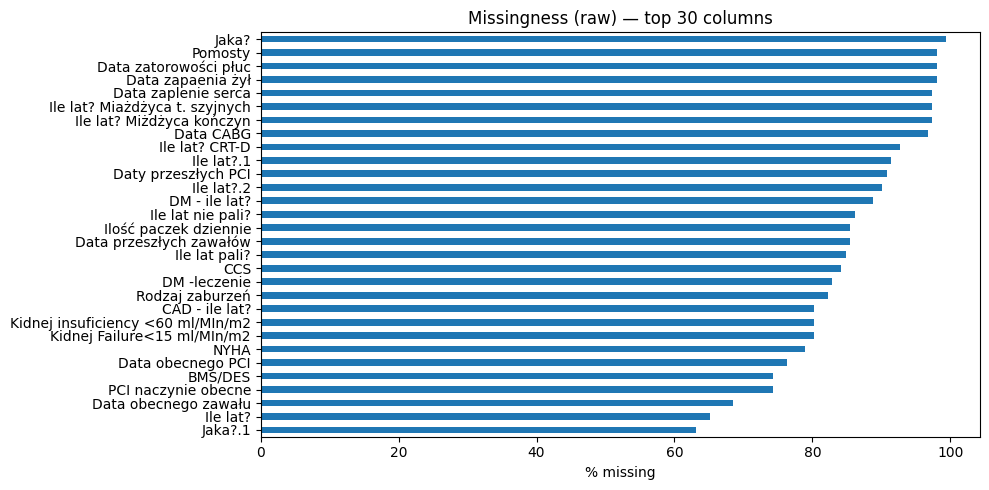

In [4]:
missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
print("Top-15 columns by % missing (raw):")
display(missing_pct.head(15).to_frame("pct_missing").round(2))

print("Raw dtype counts:")
display(df_raw.dtypes.astype(str).value_counts().to_frame("n_columns"))

topn = 30
plt.figure(figsize=(10, 5))
missing_pct.head(topn).iloc[::-1].plot(kind="barh")
plt.xlabel("% missing")
plt.title(f"Missingness (raw) — top {topn} columns")
plt.tight_layout()
plt.show()


## Duplicates & potential identifiers


In [5]:
dup_cols = df_raw.columns[df_raw.columns.duplicated()].tolist()
print("Duplicated column names:", dup_cols if dup_cols else "None")

n_dup_rows = int(df_raw.duplicated().sum())
print("Exact duplicate rows:", n_dup_rows)

possible_id_cols = [c for c in df_raw.columns if re.search(r"(pacjent|patient|case|nr|pesel)", str(c), flags=re.I)]
print("Possible ID columns:", possible_id_cols)

for c in possible_id_cols[:30]:
    try:
        n_dup_id = int(df_raw[c].duplicated().sum())
        print(f"Duplicated values in '{c}':", n_dup_id)
    except Exception as e:
        print(f"Could not check duplicates for '{c}': {e}")

# ============================================================================
# METHODOLOGICAL NOTE: Duplicate Patient IDs
# ============================================================================
# The manuscript states "each row corresponded to a unique patient" (Section 5.1).
# If duplicates are detected above (e.g., Patient ID has >0 duplicates), they
# should be investigated to determine whether they represent:
#   (a) Data entry errors (same patient, duplicated record)
#   (b) Distinct patients with ID collision
#   (c) Longitudinal measurements (violating cross-sectional assumptions)
#
# For this proof-of-concept case study, duplicates are flagged but retained.
# Production workflows should resolve duplicates before model training.
# ============================================================================


Duplicated column names: None
Exact duplicate rows: 0
Possible ID columns: ['Nr pacjenta', 'Patient ID', 'Nr na próbce']
Duplicated values in 'Nr pacjenta': 0
Duplicated values in 'Patient ID': 0
Duplicated values in 'Nr na próbce': 64


## Column name cleaning + mapping


In [6]:
def clean_column_name(col: str) -> str:
    col = str(col).strip()
    col = col.replace("\n", " ").replace("\t", " ")
    col = re.sub(r"\s+", " ", col)
    col = col.lower()
    col = (
        col.replace("ł","l").replace("ą","a").replace("ę","e")
           .replace("ś","s").replace("ć","c").replace("ń","n")
           .replace("ó","o").replace("ż","z").replace("ź","z")
    )
    col = re.sub(r"[^0-9a-zA-Z]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def make_unique(names: list[str]) -> list[str]:
    seen = {}
    out = []
    for n in names:
        if n not in seen:
            seen[n] = 0
            out.append(n)
        else:
            seen[n] += 1
            out.append(f"{n}_{seen[n]}")
    return out

colmap = pd.DataFrame({"raw_column": df_raw.columns.astype(str)})
colmap["clean_column"] = colmap["raw_column"].map(clean_column_name)
colmap["clean_column"] = make_unique(colmap["clean_column"].tolist())

df_clean = df_raw.copy()
df_clean.columns = colmap["clean_column"].tolist()

print("Cleaned shape:", df_clean.shape)
display(colmap.head(30))

colmap_path = OUT_DIR / "column_name_map.csv"
colmap.to_csv(colmap_path, index=False)
print("Saved:", colmap_path.resolve())


Cleaned shape: (152, 117)


,raw_column,clean_column
0,Nr pacjenta,nr_pacjenta
1,Internal ID,internal_id
2,Patient ID,patient_id
3,Nr na próbce,nr_na_probce
4,Typ zawału,typ_zawalu
5,Data pobrania,data_pobrania
6,Płeć,plec
7,Data urodzenia,data_urodzenia
8,EMMPRIN,emmprin
9,92 kDa pro-MMP-9,92_kda_pro_mmp_9


Saved: /content/processed/column_name_map.csv


## Type coercion (yes/no → bool, numeric parsing)


In [7]:
YES = {"tak", "t", "yes", "y", "1", 1, True}
NO  = {"nie", "n", "no", "0", 0, False}

coercion_log = []

def coerce_yes_no(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in YES:
        return True
    if s in NO:
        return False
    return x

for c in df_clean.columns:
    if df_clean[c].dtype == "object":
        before = df_clean[c].copy()
        after = df_clean[c].map(coerce_yes_no)
        bool_rate = after.isin([True, False]).mean()
        if bool_rate > 0.8:
            df_clean[c] = after
            if not before.equals(df_clean[c]):
                coercion_log.append({"column": c, "type": "yes/no->bool", "bool_rate": float(bool_rate)})

for c in df_clean.columns:
    if df_clean[c].dtype == "object":
        tmp = df_clean[c].astype(str).str.replace(",", ".", regex=False)
        numeric = pd.to_numeric(tmp, errors="coerce")
        numeric_rate = numeric.notna().mean()
        if numeric_rate > 0.8:
            df_clean[c] = numeric
            coercion_log.append({"column": c, "type": "object->numeric", "numeric_rate": float(numeric_rate)})

coercion_df = pd.DataFrame(coercion_log)
print("Number of coercions applied:", len(coercion_df))
display(coercion_df.head(20))

print("Dtype counts after coercion:")
display(df_clean.dtypes.astype(str).value_counts().to_frame("n_columns"))

coercion_path = OUT_DIR / "coercion_log.csv"
coercion_df.to_csv(coercion_path, index=False)
print("Saved:", coercion_path.resolve())


Number of coercions applied: 2


,column,type,bool_rate
0,otylosc_bmi_30,yes/no->bool,0.953947
1,czy_pali,yes/no->bool,0.993421


Dtype counts after coercion:


,n_columns
object,68
float64,45
int64,2
datetime64[ns],2


Saved: /content/processed/coercion_log.csv


## Missingness overview (clean) + numeric summary


Top-15 columns by % missing (clean):


,pct_missing
jaka,99.34
pomosty,98.03
data_zatorowosci_pluc,98.03
data_zapaenia_zyl,98.03
data_zaplenie_serca,97.37
ile_lat_miazdzyca_t_szyjnych,97.37
ile_lat_mizdzyca_konczyn,97.37
data_cabg,96.71
ile_lat_crt_d,92.76
ile_lat_1,91.45


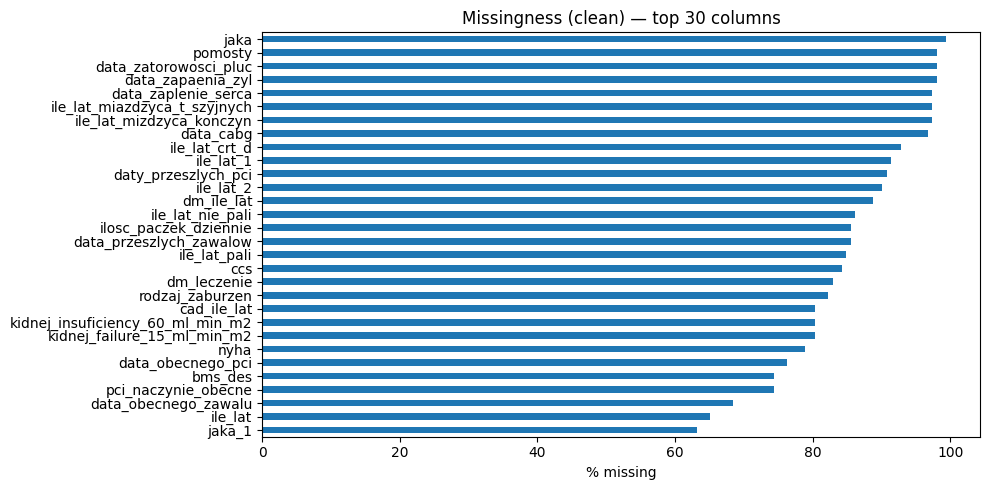

Number of numeric columns: 47


,count,mean,std,min,25%,50%,75%,max
nr_pacjenta,152.0,76.618421,44.204961,1.000000,38.750000,76.500000,114.250000,153.000000
emmprin,79.0,3476.927894,807.830978,1490.000000,2992.500000,3436.250000,3999.375000,5742.500000
92_kda_pro_mmp_9,70.0,3220.603743,2593.549723,6.794000,661.177750,2476.944000,5492.448250,8257.984000
72_kda_pro_mmp_2,63.0,927.119063,967.848761,11.112000,116.554000,250.888000,1817.306500,2617.025000
wyniki_klotho_pg_ml,87.0,588.343002,342.246981,181.553380,354.118300,521.584000,708.461600,2539.620000
wyniki_fgf23_pg_ml,77.0,930.172397,1129.727307,28.762020,177.658700,568.750300,1138.637000,5610.999000
tnfalfa_pg_ml,148.0,26.916858,86.905807,0.733732,1.986246,6.184331,15.553862,701.008420
il_6_pg_ml,83.0,21.776181,51.350642,0.538005,4.740355,8.410000,17.781238,384.390000
wiek_w_momencie_zbiorki,152.0,61.243421,14.188418,18.000000,55.000000,63.000000,70.000000,90.000000
waga_kg,145.0,77.986207,15.362737,44.000000,67.000000,80.000000,89.000000,131.000000


In [8]:
missing_pct_clean = (df_clean.isna().mean() * 100).sort_values(ascending=False)
print("Top-15 columns by % missing (clean):")
display(missing_pct_clean.head(15).to_frame("pct_missing").round(2))

topn = 30
plt.figure(figsize=(10, 5))
missing_pct_clean.head(topn).iloc[::-1].plot(kind="barh")
plt.xlabel("% missing")
plt.title(f"Missingness (clean) — top {topn} columns")
plt.tight_layout()
plt.show()

num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print("Number of numeric columns:", len(num_cols))
if num_cols:
    display(df_clean[num_cols[:15]].describe().T)


## QC: simple range rules

In [9]:
concept_map = {
    "age": ["wiek_w_momencie_zbiorki"],
    "bmi": ["bmi"],
}
range_rules = {
    "age": (0, 120),
    "bmi": (10, 80),
}

qc_rows = []
for concept, cols in concept_map.items():
    lo, hi = range_rules[concept]
    for col in cols:
        if col not in df_clean.columns:
            print(f"[QC] WARNING: expected column not found: {col}")
            continue
        s = pd.to_numeric(df_clean[col], errors="coerce")
        bad = s[(s < lo) | (s > hi)]
        if bad.notna().any():
            qc_rows.append(pd.DataFrame({
                "concept": concept,
                "column": col,
                "rule_lo": lo,
                "rule_hi": hi,
                "row_index": bad.index.values,
                "bad_value": bad.values,
            }))
        else:
            print(f"[QC] OK: '{col}' within range ({lo}-{hi}).")

if qc_rows:
    qc_out = pd.concat(qc_rows, ignore_index=True)
    print("QC out-of-range findings:")
    display(qc_out.head(50))
else:
    qc_out = pd.DataFrame(columns=["concept","column","rule_lo","rule_hi","row_index","bad_value"])

qc_path = OUT_DIR / "qc_out_of_range.csv"
qc_out.to_csv(qc_path, index=False)
print("Saved:", qc_path.resolve())


# ============================================================================
# METHODOLOGICAL NOTE: QC Values Flagged but Not Auto-Corrected
# ============================================================================
# Per the leakage-aware framework (Section 5.1), quality control at Stage 1 is
# strictly descriptive. Values outside physiological ranges (e.g., age=1952
# detected above) are identified and logged for transparency, but are NOT
# automatically removed, winsorized, or imputed. This ensures:
#   (a) QC decisions remain auditable and traceable
#   (b) No implicit outcome-driven filtering occurs before model training
#   (c) Downstream analysts can make informed decisions about data handling
#
# Flagged values should be reviewed manually. The age=1952 value likely
# represents a data entry error (year instead of age) and warrants correction
# in production workflows.
# ============================================================================


[QC] OK: 'wiek_w_momencie_zbiorki' within range (0-120).
[QC] OK: 'bmi' within range (10-80).
Saved: /content/processed/qc_out_of_range.csv


## FIREWALL anty-leakage + audit

In [10]:
TARGET_COL = "typ_zawalu"
ALLOWLIST_EXACT: set[str] = set()

ID_EXACT = {
    "internal_id", "patient_id", "nr_pacjenta", "nr_na_probce", "pesel",
    "id", "ID", "Id"
}

ID_TOKEN_REGEX = re.compile(
    r"(^|_)id($|_)|(^|_)pesel($|_)|^nr(_|$)|(^|_)nr($|_)",
    flags=re.IGNORECASE
)

BIOMARKER_NAME_REGEX = re.compile(
    r"(tropon|tnt\b|tni\b|ckmb|ck[_-]?mb|nt[_-]?probnp|bnp\b|crp\b|hscrp|fgf|galectin|il[-_ ]?\d|tnf\b|mirna|metabol|lipid|chol|ldl|hdl|trigl|glucose|creat|urea|ast\b|alt\b|plt\b|wbc\b|hgb\b|inr\b|aptt|klotho|mmp)",
    flags=re.IGNORECASE
)


HARD_EXCLUDE_REGEX = [

    r"(^|_)id($|_)",
    r"(^|_)pesel($|_)",
    r"^nr(_|$)",


    r"(^|_)data(_|$)",
    r"(^|_)date(_|$)",
    r"(^|_)czas(_|$)",
    r"timestamp",
    r"(^|_)dzien(_|$)",
    r"(^|_)godz(_|$)",


    r"(^|_)wypis(_|$)",
    r"follow",
    r"kontrol",
    r"rehosp",
    r"(^|_)zgon(_|$)",
    r"mort",
    r"procedur",
    r"pci",
    r"cabg",
    r"stent",
    r"angiograf",
    r"stemi",
    r"nstemi",
    r"ua",
    r"typ_zawalu",
    r"zawal",
    r"(_|^)(max|maks|peak|szczyt|najwyz|highest|top)(_|$)",
    r"(lvef|ef|ejection|frakcja_wyrzutowa|wyrzutowa|echo|echokard|strain)",
    r"(^|_)asa($|_)|brilique|ticagrelor|prasugrel|clopidogrel|plavix|aspirin|statin|statyna"

    r"(^|_)asa($|_)", r"(brilique|ticagrelor|prasugrel|clopidogrel|plavix|aspirin)",
    r"(heparin|heparyn|trombol)", r"(statin|statyn)",
    r"(diuretyk|furosemid|spironol|eplerenon)",
    r"(metoprolol|bisoprolol|beta[_-]?block)",
    r"(acenocoumarol|warfarin|eliquis|xarelto)",
]

HARD_EXCLUDE_COMPILED = [re.compile(p, flags=re.IGNORECASE) for p in HARD_EXCLUDE_REGEX]

def hard_exclude_reason(col: str) -> str | None:
    if col == TARGET_COL:
        return "target_col"
    if col in ALLOWLIST_EXACT:
        return None
    if col in ID_EXACT:
        return "id_exact"
    for rx in HARD_EXCLUDE_COMPILED:
        if rx.search(col):
            return f"regex:{rx.pattern}"
    return None

def looks_like_datetime(series: pd.Series, threshold: float = 0.8, sample_n: int = 200) -> bool:
    """Heuristic: parse a small sample to datetime; avoids deprecation & expensive full-column parsing."""
    if pd.api.types.is_datetime64_any_dtype(series):
        return True
    if series.dtype != "object":
        return False

    s = series.dropna()
    if s.empty:
        return False

    if len(s) > sample_n:
        s = s.sample(sample_n, random_state=RANDOM_STATE)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        parsed = pd.to_datetime(s, errors="coerce")

    return float(parsed.notna().mean()) >= threshold





## Apply firewall exclusions + audit export

In [11]:
audit_rows = []
excluded_cols = []
kept_cols = []

for c in df_clean.columns:
    reason = hard_exclude_reason(c)
    if reason is None and looks_like_datetime(df_clean[c]):
        reason = "datetime_like_values"

    if reason is None:
        kept_cols.append(c)
        audit_rows.append({"feature": c, "status": "kept", "reason": ""})
    else:
        excluded_cols.append(c)
        audit_rows.append({"feature": c, "status": "excluded", "reason": reason})

audit_df = pd.DataFrame(audit_rows).sort_values(["status", "feature"])
audit_path = OUT_DIR / "S1_feature_exclusion_audit.csv"
audit_df.to_csv(audit_path, index=False)

print("Saved:", audit_path.resolve(), "| excluded:", len(excluded_cols), "| kept:", len(kept_cols))
display(audit_df[audit_df["status"]=="excluded"]["reason"].value_counts().head(30).to_frame("n_excluded"))


Saved: /content/processed/S1_feature_exclusion_audit.csv | excluded: 44 | kept: 73


,n_excluded
reason,
regex:(^|_)data(_|$),9
regex:(^|_)wypis(_|$),9
datetime_like_values,7
id_exact,4
regex:pci,3
regex:(_|^)(max|maks|peak|szczyt|najwyz|highest|top)(_|$),3
regex:(^|_)asa($|_)|brilique|ticagrelor|prasugrel|clopidogrel|plavix|aspirin|statin|statyna(^|_)asa($|_),2
regex:(lvef|ef|ejection|frakcja_wyrzutowa|wyrzutowa|echo|echokard|strain),2
regex:(diuretyk|furosemid|spironol|eplerenon),1


## Data_dictionary.csv + missingness_summary.csv


In [12]:
data_dict = pd.DataFrame({
    "raw_column": colmap["raw_column"].astype(str),
    "column": colmap["clean_column"].astype(str),
    "dtype_raw": df_raw.dtypes.astype(str).values,
    "dtype_clean": df_clean.dtypes.astype(str).values,
    "n_missing": df_clean.isna().sum().values,
    "pct_missing": (df_clean.isna().mean() * 100).round(2).values,
})

excluded_set = set(excluded_cols)


ID_ROLE_REGEX = re.compile(
    r"(^id$)|(^id_)|(_id$)|(^pesel$)|(^pesel_)|(_pesel$)|(^nr$)|(^nr_)|(_nr$)|(^nr_pacjenta$)|(^patient_id$)|(^internal_id$)",
    flags=re.IGNORECASE
)

roles = []
for col in data_dict["column"].tolist():
    col_s = str(col)

    if col_s == TARGET_COL:
        role = "target"
    elif (col_s in ID_EXACT) or ID_ROLE_REGEX.search(col_s):
        role = "id"
    elif col_s in excluded_set:
        role = "exclude"
    elif BIOMARKER_NAME_REGEX.search(col_s):
        role = "biomarker"
    else:
        role = "clinical"
    roles.append(role)

data_dict["role"] = roles
data_dict["unit"] = np.nan
data_dict["note"] = np.nan


suspect_id = data_dict[(data_dict["role"] == "id") & ~(data_dict["column"].isin(ID_EXACT) | data_dict["column"].astype(str).str.match(ID_ROLE_REGEX))]
if not suspect_id.empty:
    raise ValueError(
        "[S1] Suspect ID-role assignments. Fix ID_ROLE_REGEX/ID_EXACT. Examples: "
        + ", ".join(suspect_id["column"].astype(str).head(20).tolist())
    )

print("Role counts:")
display(data_dict["role"].value_counts(dropna=False).to_frame("n_columns"))

data_dict = data_dict.sort_values("column").reset_index(drop=True)
display(data_dict.head(30))

dd_path = OUT_DIR / "data_dictionary.csv"
data_dict.to_csv(dd_path, index=False, encoding="utf-8")
print("Saved:", dd_path.resolve())

missing_summary = data_dict.sort_values("pct_missing", ascending=False)
ms_path = OUT_DIR / "missingness_summary.csv"
missing_summary.to_csv(ms_path, index=False, encoding="utf-8")
print("Saved:", ms_path.resolve())


Role counts:


,n_columns
role,
clinical,63
exclude,39
biomarker,10
id,4
target,1


,raw_column,column,dtype_raw,dtype_clean,n_missing,pct_missing,role,unit,note
0,72 kDa pro-MMP-2,72_kda_pro_mmp_2,float64,float64,89,58.55,biomarker,NaN,NaN
1,92 kDa pro-MMP-9,92_kda_pro_mmp_9,float64,float64,82,53.95,biomarker,NaN,NaN
2,ACE-I,ace_i,object,object,65,42.76,clinical,NaN,NaN
3,AlbumIny [g/L],albuminy_g_l,float64,float64,87,57.24,clinical,NaN,NaN
4,ARB,arb,object,object,80,52.63,clinical,NaN,NaN
5,ASA,asa,object,object,65,42.76,exclude,NaN,NaN
6,BB,bb,object,object,66,43.42,clinical,NaN,NaN
7,BMI,bmi,float64,float64,7,4.61,clinical,NaN,NaN
8,BMS/DES,bms_des,object,object,113,74.34,clinical,NaN,NaN
9,Brilique,brilique,object,object,78,51.32,exclude,NaN,NaN


Saved: /content/processed/data_dictionary.csv
Saved: /content/processed/missingness_summary.csv


## Feature variants + lock validation

In [13]:
dd = pd.read_csv(dd_path, encoding="utf-8")

valid_roles = {"clinical", "biomarker", "exclude", "target", "id"}
bad_roles = set(dd["role"].unique()) - valid_roles
if bad_roles:
    raise ValueError(f"Unexpected roles in data_dictionary.csv: {bad_roles}")

clinical_feats = dd.loc[dd["role"] == "clinical", "column"].tolist()
biomarker_feats = dd.loc[dd["role"] == "biomarker", "column"].tolist()

clinical_feats = [c for c in clinical_feats if c in kept_cols]
biomarker_feats = [c for c in biomarker_feats if c in kept_cols]

TNF_COL = "tnfalfa_pg_ml"
if TNF_COL in clinical_feats:
    clinical_feats = [c for c in clinical_feats if c != TNF_COL]
if TNF_COL in kept_cols and TNF_COL not in biomarker_feats:
    biomarker_feats = biomarker_feats + [TNF_COL]


full_feats = sorted(list(dict.fromkeys(clinical_feats + biomarker_feats)))

variants = {
    "FULL": full_feats,
    "CLINICAL": sorted(list(dict.fromkeys(clinical_feats))),
    "BIOMARKERS": sorted(list(dict.fromkeys(biomarker_feats))),
}

excluded_by_role = set(dd.loc[dd["role"].isin(["exclude","target","id"]), "column"].tolist())
excluded_by_firewall = set(excluded_cols)
blocked = excluded_by_role.union(excluded_by_firewall)

for k, v in variants.items():
    if not v:
        raise ValueError(f"Variant '{k}' is empty. Check role assignment and firewall exclusions.")
    overlap = blocked.intersection(v)
    if overlap:
        raise ValueError(f"Variant '{k}' contains blocked columns: {sorted(list(overlap))[:50]}")

print("Variant sizes:", {k: len(v) for k, v in variants.items()})


Variant sizes: {'FULL': 73, 'CLINICAL': 62, 'BIOMARKERS': 11}


## Leakage scan (variants) + CSV save

In [14]:
LEAK_SCAN_REGEX = re.compile(
    r"(stemi|nstemi|\bua\b|typ_zawalu|zawal|(^|_)data(_|$)|(^|_)date(_|$)|(^|_)czas(_|$)|timestamp|wypis|follow|kontrol|rehosp|zgon|mort|procedur|\bpci\b|cabg|stent|angiograf|heparin|heparyn|trombol|statin|statyn|(_|^)(max|maks|peak|szczyt|najwyz|highest|top)(_|\b|$)|lvef|echo|strain|brilique|ticagrelor|prasugrel|clopidogrel|plavix|aspirin|(^|_)asa($|_))",
    flags=re.IGNORECASE
)

hits = []
for vname, cols in variants.items():
    for c in cols:
        if c == TARGET_COL:
            hits.append({"variant": vname, "feature": c, "reason": "TARGET_COL included"})
        elif LEAK_SCAN_REGEX.search(c):
            hits.append({"variant": vname, "feature": c, "reason": "keyword_match"})
        elif looks_like_datetime(df_clean[c]):
            hits.append({"variant": vname, "feature": c, "reason": "datetime_like_values"})

hits_df = pd.DataFrame(hits, columns=["variant","feature","reason"])
scan_path = OUT_DIR / "S1_leakage_keyword_scan.csv"
hits_df.to_csv(scan_path, index=False)

print("Saved:", scan_path.resolve(), "| hits:", len(hits_df))

if len(hits_df) > 0:
    display(hits_df.head(200))
    raise ValueError("[S1] Leakage scan FAILED — revise firewall/roles.")
else:
    print("[S1] Leakage scan PASSED (0 hits).")


Saved: /content/processed/S1_leakage_keyword_scan.csv | hits: 0
[S1] Leakage scan PASSED (0 hits).


## Feature variants.json record

In [15]:
variants_path = OUT_DIR / "feature_variants.json"
with open(variants_path, "w", encoding="utf-8") as f:
    json.dump(variants, f, indent=2, ensure_ascii=False)
print("Saved:", variants_path.resolve())

processed_path = OUT_DIR / "processed_dataset.csv"
df_clean.to_csv(processed_path, index=False)
print("Saved processed dataset to:", processed_path.resolve())


Saved: /content/processed/feature_variants.json
Saved processed dataset to: /content/processed/processed_dataset.csv


## Parquet + sha256 notation

In [16]:
def make_parquet_safe(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    obj_cols = df2.select_dtypes(include="object").columns
    for c in obj_cols:
        df2[c] = df2[c].astype("string[python]")
    return df2

def sha256_of_file(path: Path, chunk_size: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

df_raw_safe = make_parquet_safe(df_raw)
df_clean_safe = make_parquet_safe(df_clean)

df_raw_path = OUT_DIR / "df_raw.parquet"
df_clean_path = OUT_DIR / "df_clean.parquet"

df_raw_safe.to_parquet(df_raw_path, index=False, engine="pyarrow")
df_clean_safe.to_parquet(df_clean_path, index=False, engine="pyarrow")

print("Saved:", df_raw_path.resolve(), "| sha256:", sha256_of_file(df_raw_path)[:16], "…")
print("Saved:", df_clean_path.resolve(), "| sha256:", sha256_of_file(df_clean_path)[:16], "…")

print("\n[S1] FINAL: Governance + firewall + scans PASSED — safe to proceed to S2.")


Saved: /content/processed/df_raw.parquet | sha256: 7cdb7c6be7bd8ae4 …
Saved: /content/processed/df_clean.parquet | sha256: 6d4d98e07dc49bce …

[S1] FINAL: Governance + firewall + scans PASSED — safe to proceed to S2.
